In [ ]:
# see the actual derivation of these equations 
from IPython.display import YouTubeVideo
YouTubeVideo("WRr2e7mKCUY")

# Load Fashion MNIST

Now let's load in a more diverse, harder to classify dataset: Fashion MNIST
https://www.kaggle.com/zalando-research/fashionmnist

**Labels**

Each training and test example is assigned to one of the following labels:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot 

In [1]:

# more diverse fashion MNIST data
# Let's use Raschka's implementation for using the mnist dataset:
# https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
import os
import struct
import numpy as np
import sys
from types import SimpleNamespace
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('ggplot')
 
def load_mnist(path, kind='fashion_train'):
    """Load Fashion MNIST data from `path`"""
    labels_path = os.path.join(path, '%s-labels-idx1-ubyte' % kind)
    images_path = os.path.join(path, '%s-images-idx3-ubyte' % kind)
        
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', lbpath.read(8))
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack(">IIII", imgpath.read(16))
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 784)

    labels_ohe = encoder.fit_transform(labels.reshape(-1, 1))
 
    return images, labels, labels_ohe

X_train, y_train, y_train_ohe = load_mnist('data/', kind='fashion_train')
print('Rows: %d, columns: %d' % (X_train.shape[0], X_train.shape[1]))

X_test, y_test, y_test_ohe = load_mnist('data/', kind='fashion_t10k')
print('Rows: %d, columns: %d' % (X_test.shape[0], X_test.shape[1]))

# don't forget to normalize
X_train = X_train/255.0 - 0.5
X_test = X_test/255.0 - 0.5

print(np.min(X_train),np.max(X_train))


Rows: 60000, columns: 784
Rows: 10000, columns: 784
-0.5 0.5


# Practical Implementation of Custom API Networks
We will go over various heuristics in this notebook to help improve the accuracy and stability of various neural networks. Let's start with a quick review of the neural networks from the previous notebook `07c. MLP Neural Networks API` and then build some complexity. 

Like in the previous notebook, we add in momentum, cooling and mini-batching to the implementation to get a better optimizer. 

As a bonus, let's add support for keeping track of the validation in the training loop. That is, we will add in a calculation to test the validation loss and accuracy at the end of each epoch.

In [2]:

#Define some other utility functions
def train_step(model, optimizer, loss, x_train, y_train, batch_size=256):
    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    
    error = 0
    for i in range(0, len(indices), batch_size):
        batch_idx = indices[i : i + batch_size]
    
        x_batch = x_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        model.zero_grad()
        output = model(x_batch.T)
        error += loss(y_batch.T, output)
        grad   = loss.backward()
        model.backward(grad)
    
        optimizer.step()
    
    error /= len(x_train)
    
    return error

def test_step(model, loss, x_test, y_test, eval_func):
    y_pred = model(x_test.T)
    error = loss(y_test.T, y_pred)
    
    y_pred_sparse = np.argmax(y_pred, axis=0)
    y_sparse = np.argmax(y_test.T, axis=0)
    eval_score = eval_func(y_sparse, y_pred_sparse)

    return error, eval_score

def classification_report(model, x_test, y_test, history, title="", color="red"):
    #  testing 
    y_hat = model(x_test.T,sparse=True)
    print(f'{title} Accuracy on Test Data: {accuracy_score(y_test,y_hat):.4f}')
    
    # plotting
    plt.plot(range(len(history.val_acc)), history.val_acc, color=color,label=title)
    plt.legend(loc='best')
    plt.ylabel('Validation Accuracy'), plt.xlabel('Epochs')
    plt.tight_layout()
    plt.grid(True)

def show_status(epoch, epochs, print_every, error):
    # print status
    if (epoch % print_every == 0) or (epoch+1  >= epochs):
        sys.stderr.write(f"\r{epoch + 1}/{epochs}, error={error}")
        sys.stderr.flush()

def train_model(model, loss, opt, epochs, print_every, batch_size=128):

    history = SimpleNamespace(loss=np.zeros(epochs), 
                          val_loss=np.zeros(epochs), 
                          val_acc=np.zeros(epochs))

    
    for epoch in range(epochs):
        # send model to perform a training step
        history.loss[epoch]  = train_step(model, opt, loss, X_train, y_train_ohe, batch_size=batch_size)
        opt.scheduler_step(epoch)
    
        # keep track of result
        history.val_loss[epoch], history.val_acc[epoch] = test_step(model, loss, X_test, y_test_ohe, accuracy_score)
        show_status(epoch,epochs,print_every,history.loss[epoch])
        
    return history


20/20, error=0.0005005950260214214

MSE Accuracy on Test Data: 0.4821


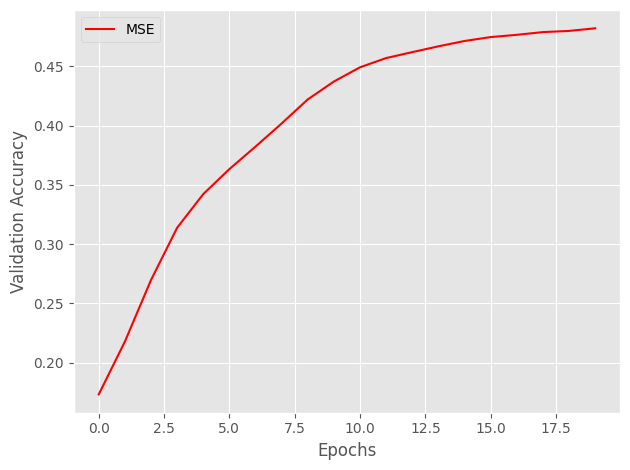

In [3]:
from LarsonUtils import Model, Dense, Sigmoid, MSELoss, SGD # code from previous notebook
from LarsonUtils import Optimizer, Layer, Loss, Parameter # Base classes to inherit from

# create model
model = Model([Dense(784,256), Sigmoid(),
               Dense(256,128), Sigmoid(),
               Dense(128,10), Sigmoid()])

# set loss function
mse_loss = MSELoss()
opt = SGD(model.parameters, learning_rate=0.01, momentum=0.1, decay_rate=0.9, step_size=10)

history = train_model(model, mse_loss, opt, epochs=20, print_every=5)
classification_report(model, X_test, y_test, history, title='MSE', color='red')

plt.show()

## [End review] [Back to Slides]
___

## Start of new material

Let's start our architecture updates by changing to cross entropy. THis is a realtively easy change to make. Let's do this and then load the fashion MNIST dataset for testing. 

# Practical Implementation of Neural Networks

We define a new objective function as:

$$ J(\mathbf{W})=-[\mathbf{y}^{(i)}\ln[\mathbf{a}^{(L+1)}]^{(i)}+(1-\mathbf{y}^{(i)})\ln(1-[\mathbf{a}^{(L+1)}]^{(i)}) ]$$

Notice that this is highly similar to the log-likelihood we derived for logistic regression.

Such that the new update for the final layer becomes:

$$ \left[\frac{\partial J(\mathbf{W})}{\mathbf{z}^{(L)}}\right]^{(i)} = ([\mathbf{a}^{(L+1)}]^{(i)}- \mathbf{y}^{(i)}) $$

$$ \left[\frac{\partial J(\mathbf{W})}{\mathbf{z}^{(2)}}\right]^{(i)} = ([\mathbf{a}^{(3)}]^{(i)}- \mathbf{y}^{(i)})$$

And this is straight forward to convert to vectorized math for the sensitivity:

$$ \mathbf{V}^{(2)} = \mathbf{A}^{(3)}-\mathbf{Y} $$

Which can be derived as follows

$$
\begin{align}
J(\mathbf{W})&=-\left[\mathbf{y}^{(i)}\ln\phi([\mathbf{z}^{(L)}]^{(i)})+(1-\mathbf{y}^{(i)})\ln(1-[\phi(\mathbf{z}^{(L)}]^{(i)})) \right] \\
\frac{\partial J}{\partial \mathbf{z}^{(L)}} &=  -\left[\frac{\mathbf{y}^{(i)}}{\phi([\mathbf{z}^{(L)})]^{(i)}}\left( \frac{\partial}{\partial \mathbf{z}^{(L)}}\phi([\mathbf{z}^{(L)}]^{(i)}) \right)
+\frac{(1-\mathbf{y}^{(i)})}{(1-[\phi(\mathbf{z}^{(L)})]^{(i)})}\left( \frac{\partial}{\partial \mathbf{z}^{(L)}}(1-[\phi(\mathbf{z}^{(L)}]^{(i)}))\right) \right] \\
 &=  -\left[\frac{\mathbf{y}^{(i)}}{\phi([\mathbf{z}^{(L)}]^{(i)})} \phi([\mathbf{z}^{(L)}]^{(i)})\left(1-\phi([\mathbf{z}^{(L)}]^{(i)}) \right)
+\left(\frac{1-\mathbf{y}^{(i)}}{1-[\phi(\mathbf{z}^{(L)}]^{(i)})}\right)  \left(-\phi([\mathbf{z}^{(L)}]^{(i)})\left(1-\phi([\mathbf{z}^{(L)}]^{(i)}) \right)\right) \right] \\
 &=  -\left[\mathbf{y}^{(i)}\left(1-\phi([\mathbf{z}^{(L)}]^{(i)}) \right)
+\left(1-\mathbf{y}^{(i)}\right)  \left(-\phi([\mathbf{z}^{(L)}]^{(i)})\right) \right] \\
&=  -\left[\mathbf{y}^{(i)}-\mathbf{y}^{(i)}\phi([\mathbf{z}^{(L)}]^{(i)}) 
-\phi([\mathbf{z}^{(L)}]^{(i)})+\phi([\mathbf{z}^{(L)}]^{(i)})\mathbf{y}^{(i)}   \right] \\
&=  -\left[\mathbf{y}^{(i)}-\phi([\mathbf{z}^{(L)}]^{(i)})   \right] \\
&=  \phi([\mathbf{z}^{(L)}]^{(i)}) - \mathbf{y}^{(i)} \\
&=  [\mathbf{a}^{(L+1)}]^{(i)} - \mathbf{y}^{(i)} \\
\end{align}
$$

However, to implement this with out model, the final simplification requires that we combine the sigmoid operation and the loss function. As such, in the code below, we assume that the model give use output that have not gone through a final sigmoid layer. In the model, we also leave off the final `Sigmoid` function. 

Another option is to choose the softmax, which is defined as:

$$  a_j^{(L+1)} = \frac{\exp(z_j^{(L)})}{\sum_i \exp(z_i^{(L)})}  $$

However, it has an identical update equation as the sigmoid final layer using cross entropy (just normalizes the outputs differently). We will stick with cross entropy in order to keep the consistency to previous feedforward code. However, please note that that sigmoid activation functions are more susceptible to gradient instability. 

20/20, error=0.023245594114975086

MSE Accuracy on Test Data: 0.4821
CE Accuracy on Test Data: 0.7334


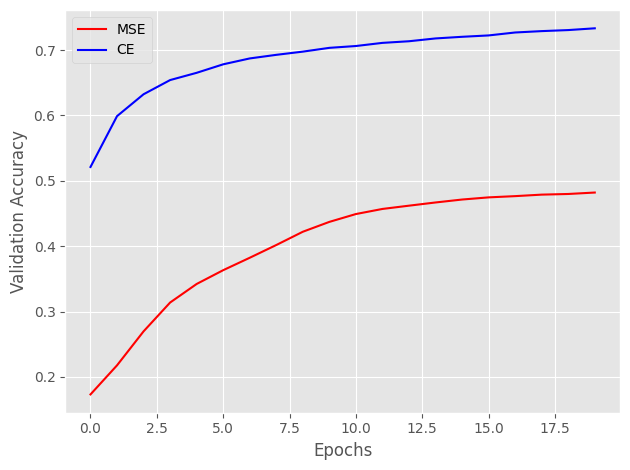

In [4]:
# to implement the new style of objective function, 
# we just need to update the loss calculation of the gradient
        
class CategoricalCrossEntropy(Loss):
    def __call__(self, y_true, y_pred):

        self.y_true = y_true
        self.y_pred = np.clip(y_pred,1e-12,1.0)

        batch_size = y_true.shape[1]

        self.output = -np.sum(
            y_true * np.log(self.y_pred)
        ) / batch_size

        return self.output

    def backward(self):
        return (self.y_pred - self.y_true) / self.y_true.shape[1]  

model_ce = Model([Dense(784,256), Sigmoid(),
               Dense(256,128), Sigmoid(),
               Dense(128,10)])

# set loss function
ce_loss = CategoricalCrossEntropy()
opt = SGD(model_ce.parameters, learning_rate=0.01, momentum=0.1, decay_rate=0.9, step_size=10)

history_ce = train_model(model_ce, ce_loss, opt, epochs=20, print_every=5)

classification_report(model,    X_test, y_test, history,    title='MSE', color='red')
classification_report(model_ce, X_test, y_test, history_ce, title='CE',  color='blue')

plt.show()

### [Back to Slides]
## Now let's Do initialization 

20/20, error=0.010237816327266903

MSE Accuracy on Test Data: 0.4821
CE Accuracy on Test Data: 0.7334
CE_Init Accuracy on Test Data: 0.8046


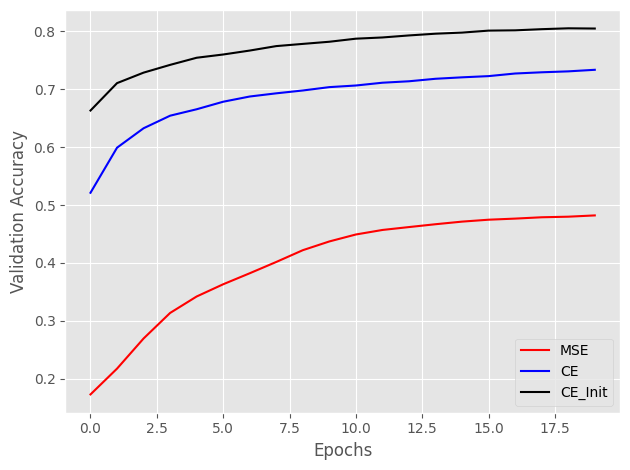

In [6]:
from LarsonUtils import  Dense as SimpleDense # code from previous notebook

class Dense(SimpleDense):
    def __init__(self, input_size, output_size, init_type='GlorotUniform'):
        """Initialize weights with small random numbers."""
        super().__init__(input_size, output_size)

        if init_type == 'GlorotUniform':
            init_bound = 4*np.sqrt(6. / (output_size + input_size))
        elif init_type == 'HeUniform':
            init_bound = np.sqrt(2)*np.sqrt(6. / (output_size + input_size))
        else:
            init_bound = 1.0
            
        num_elems = output_size*input_size
        tmp_weights = np.random.uniform(-init_bound, init_bound, size=(output_size, input_size))
        
        self.weights = Parameter(tmp_weights)
        self.bias = Parameter(np.zeros((output_size, 1)))
        
        
model_init = Model([Dense(784,256), Sigmoid(),
               Dense(256,128), Sigmoid(),
               Dense(128,10)])

# set loss function
ce_loss = CategoricalCrossEntropy()
opt = SGD(model_init.parameters, learning_rate=0.01, momentum=0.1, decay_rate=0.9, step_size=10)

history_init = train_model(model_init, ce_loss, opt, epochs=20, print_every=5)

classification_report(model,      X_test, y_test, history,      title='MSE',     color='red')
classification_report(model_ce,   X_test, y_test, history_ce,   title='CE',      color='blue')
classification_report(model_init, X_test, y_test, history_init, title='CE_Init', color='black')

plt.show()

______
**Self Test**: Resubstitution accuracy is more important than validation accuracy when training.
- A. True
- B. False
- C. It depends



## [Back To Slides]
_____

# Adaptive Methods: AdaGrad
In this formulation, we use the following update function as follows:
$$\mathbf{W}_{k+1}^{(l)} = \mathbf{W}_k^{(l)} -  \eta\cdot\rho_{k}^{(l)}$$

Where:

$$ \rho_k^{(l)} = \frac{1}{\sqrt{\mathbf{G}_k^{(l)}+\epsilon}}\odot\nabla J(\mathbf{W}_{k}^{(l)}) $$

and 

$$ \mathbf{G}_k^{(l)} =\alpha \cdot\mathbf{G}^{(l)}_{k-1}+\nabla J(\mathbf{W}_k^{(l)})\odot \nabla J(\mathbf{W}_k^{(l)}) $$

20/20, error=0.004744974478799261

MSE Accuracy on Test Data: 0.4821
CE Accuracy on Test Data: 0.7334
CE_Init Accuracy on Test Data: 0.8046
AdaGrad Accuracy on Test Data: 0.8669


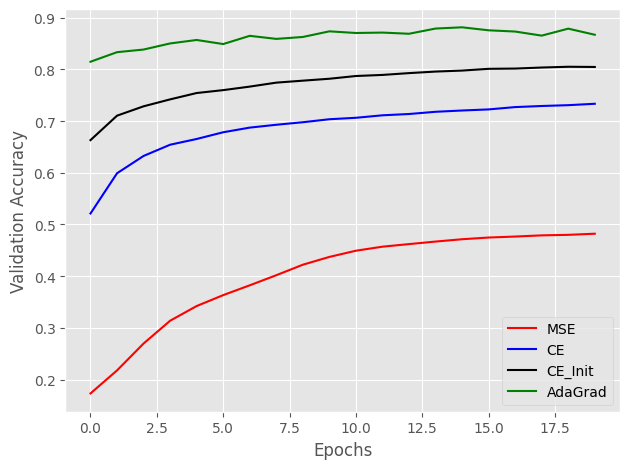

In [7]:
class AdaGrad(SGD):
    def step(self):
        # repurpose the momentum cache for storing G
        for param, G in zip(self.parameters, self._cache):
            G[:] = self.momentum*G + param.grad*param.grad  
            param.value -= self.learning_rate * param.grad / np.sqrt(G + 1e-12)
            
model_ada = Model([Dense(784,256), Sigmoid(),
               Dense(256,128), Sigmoid(),
               Dense(128,10)])

# set loss function
ce_loss = CategoricalCrossEntropy()
opt = AdaGrad(model_ada.parameters, learning_rate=0.001, momentum=0.1, decay_rate=0.9, step_size=10)

history_ada = train_model(model_ada, ce_loss, opt, epochs=20, print_every=5)

classification_report(model,      X_test, y_test, history,      title='MSE',     color='red')
classification_report(model_ce,   X_test, y_test, history_ce,   title='CE',      color='blue')
classification_report(model_init, X_test, y_test, history_init, title='CE_Init', color='black')
classification_report(model_ada,  X_test, y_test, history_ada,  title='AdaGrad', color='green')

plt.show()


____
# Rectified Linear Units
Now lets look at another type of activation function. The rectified linear unit (ReLu) is an interesting choice to use because of its simplicity. Moreover, we will learn that its backpropagated derivative has some characteristics that are advantageous. 

We define the ReLU neuron as:

$$
    \phi(\mathbf{z}^{(i)})=\left\{
                \begin{array}{ll}
                \mathbf{z}^{(i)}  \text{,  if }\mathbf{z}^{(i)}>0 \\
                \mathbf{0} \text{,      else } \\
                \end{array}
              \right.
$$

Which has a very simple derivative:
$$
    \frac{\partial\phi(\mathbf{z}^{(i)})}{\partial\mathbf{z}^{(i)}}=\left\{
                \begin{array}{ll}
                \mathbf{1} \text{,  if }\mathbf{z}^{(i)}>0 \\
                \mathbf{0} \text{,      else } \\
                \end{array}
              \right.
$$

20/20, error=0.007087935447782373

MSE Accuracy on Test Data: 0.4821
CE Accuracy on Test Data: 0.7334
CE_Init Accuracy on Test Data: 0.8046
AdaGrad Accuracy on Test Data: 0.8669
ReLU Accuracy on Test Data: 0.8643


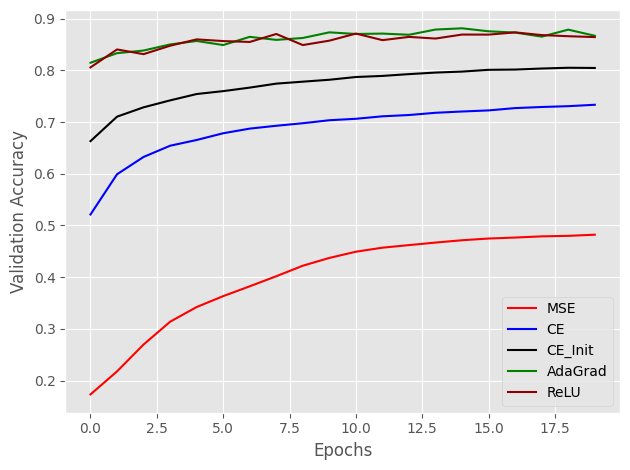

In [8]:
class Relu(Layer): 
    def __call__(self,input):
        self.input = input
        self.output = np.maximum(input, 0)
        return self.output

    def backward(self, sensitivity_in):
        return (self.output > 0) * sensitivity_in

model_relu = Model([Dense(784,256, init_type = 'HeUniform'), Relu(),
               Dense(256,128, init_type = 'HeUniform'), Relu(),
               Dense(128,10, init_type = 'GlorotUniform')])

# set loss function
ce_loss = CategoricalCrossEntropy()
opt = AdaGrad(model_relu.parameters, learning_rate=0.001, momentum=0.1, decay_rate=0.9, step_size=10)

history_relu = train_model(model_relu, ce_loss, opt, epochs=20, print_every=5)

classification_report(model,      X_test, y_test, history,      title='MSE',     color='red')
classification_report(model_ce,   X_test, y_test, history_ce,   title='CE',      color='blue')
classification_report(model_init, X_test, y_test, history_init, title='CE_Init', color='black')
classification_report(model_ada,  X_test, y_test, history_ada,  title='AdaGrad', color='green')
classification_report(model_relu, X_test, y_test, history_relu, title='ReLU',    color='darkred')

plt.show()

# Sklearn Implementation
Let's see if our method stacks up to the implementations from `scikit-learn`.

In [9]:
from sklearn import __version__ as sklearn_version
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print(sklearn_version)
# these values have been hand tuned
# sigmoid with SGD, batching, nesterov's momentum, 
# L2, adaptive learning rate
clf = MLPClassifier(hidden_layer_sizes=(256,128), 
                    activation='logistic', # compare to sigmoid
                    solver='sgd', 
                    alpha=1e-4, # L2 penalty
                    batch_size=128, # min of 128, num_samples
                    learning_rate='adaptive', # decrease rate if loss goes up
                    learning_rate_init=0.1, # only SGD
                    power_t=0.5,    # only SGD with inverse scaling
                    max_iter=20, 
                    shuffle=True, 
                    random_state=1, 
                    tol=1e-9, # for stopping
                    verbose=False, 
                    momentum=0.9, # only SGD
                    nesterovs_momentum=True, # only SGD
                    early_stopping=False, 
                    validation_fraction=0.1, # only if early_stop is true
                    beta_1=0.9, # adam decay rate of moment
                    beta_2=0.999, # adam decay rate of moment
                    epsilon=1e-08) # adam numerical stabilizer

%time clf.fit(X_train,y_train)
yhat = clf.predict(X_test)
print('Validation Acc:',accuracy_score(yhat,y_test))

1.7.1
CPU times: user 1min 9s, sys: 23.1 s, total: 1min 33s
Wall time: 1min 13s
Validation Acc: 0.8788


/Users/ericlarson/opt/anaconda3/envs/mlenv3_11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
# but with this implementation we can also easily change Neurons
# ReLU with SGD, batching, simple momentum, 
# L2, adaptive learning rate
clf = MLPClassifier(hidden_layer_sizes=(256,128 ), 
                    activation='relu', # type of non-linearity, every layer except output layer
                    solver='sgd', 
                    alpha=1e-4, # L2 penalty
                    batch_size= 128, # min of 128, num_samples
                    learning_rate='adaptive', # adapt learning? 
                    learning_rate_init=0.1, # only SGD
                    power_t=0.0,    # only SGD with inverse scaling of learning rate
                    max_iter=20, # stopping criteria
                    shuffle=True, 
                    random_state=1, 
                    tol=0, # for stopping
                    verbose=False, 
                    momentum=0.9, # only SGD
                    nesterovs_momentum=False, # only SGD
                    early_stopping=False, 
                    validation_fraction=0.0, # only if early_stop is true
                    beta_1=0.9, # adam decay rate of moment
                    beta_2=0.999, # adam decay rate of moment
                    epsilon=1e-08) # adam numerical stabilizer

%time clf.fit(X_train,y_train)
yhat = clf.predict(X_test)
print('Validation Acc:',accuracy_score(yhat,y_test))

CPU times: user 1min 6s, sys: 22.1 s, total: 1min 28s
Wall time: 1min 9s
Validation Acc: 0.8737


/Users/ericlarson/opt/anaconda3/envs/mlenv3_11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [11]:
# but what if we also use AdaM optimization?
# ReLU with AdaM, batching, simple momentum, 
# L2, adaptive learning rate
clf = MLPClassifier(hidden_layer_sizes=(256,128 ), 
                    activation='relu', # type of non-linearity, every layer except output layer
                    solver='adam', 
                    alpha=1e-4, # L2 penalty
                    batch_size= 128, # min of 200, num_samples
                    learning_rate='adaptive', # adapt learning? 
                    learning_rate_init=0.01, # only SGD
                    power_t=1,    # only SGD with inverse scaling of learning rate
                    max_iter=20, # stopping criteria
                    shuffle=True, 
                    random_state=1, 
                    tol=0, # for stopping
                    verbose=False, 
                    momentum=0.9, # only SGD
                    nesterovs_momentum=False, # only SGD
                    early_stopping=False, 
                    validation_fraction=0.0, # only if early_stop is true
                    beta_1=0.9, # adam decay rate of moment
                    beta_2=0.999, # adam decay rate of moment
                    epsilon=1e-08) # adam numerical stabilizer

%time clf.fit(X_train,y_train)
yhat = clf.predict(X_test)
print('Validation Acc:',accuracy_score(yhat,y_test))

CPU times: user 1min 20s, sys: 31.9 s, total: 1min 52s
Wall time: 1min 34s
Validation Acc: 0.8678


/Users/ericlarson/opt/anaconda3/envs/mlenv3_11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


## In this notebook, you learned:
- Simple optimization methods and tricks for Neural Networks
- Cross Entropy Loss
- Glorot and He Initialization
- Adaptive methods, like AdaGrad
- Rectified Linear Activation Functions